## Opis problemu

Celem projektu jest analiza danych GPS statków i klasyfikacja ich zachowania (pobyt w porcie, dryf, kotwiczenie, rejs) na podstawie Współrzędnych geograficznych.

Model wykorzystuje dane sekwencyjne oraz cechy kinematyczne (prędkość, kierunek, zmiany ruchu), aby przewidywać stan jednostki w czasie.

---

## Kluczowy element systemu – dane o portach

Bardzo ważnym elementem pipeline’u jest baza portów wykorzystywana do wykrywania, czy statek znajduje się w porcie.

System używa tej bazy w połączeniu z algorytmem BallTree, który sprawdza odległość punktów GPS od najbliższych portów.

---

## Ograniczenie modelu

Skuteczność wykrywania portu zależy bezpośrednio od kompletności bazy portów.

W naszym przypadku dataset zawiera tylko porty europejskie (EU).

Oznacza to, że:

- jeśli statek znajduje się w porcie spoza Europy (np. w Chinach),
- model **nie wykryje go jako “In Port”**,
- ponieważ taki port nie istnieje w bazie referencyjnej.

---

## Wniosek

Model działa poprawnie w ramach dostępnej bazy portów, jednak jego zdolność do wykrywania pobytu w porcie jest ograniczona geograficznie i zależy od kompletności danych wejściowych o portach.

Użyte biblioteki: 
- `pandas` i `numpy` do przetwarzania danych,
- `torch` do budowy modeli sieci neuronowych,
- `sklearn` do skalowania danych i ewaluacji modeli,
- `matplotlib` i `seaborn` do wizualizacji.


### Wczytywanie danych

- **`load_data(file_path)`**  
  Funkcja wczytuje dane z pliku CSV do obiektu `DataFrame`.

In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import BallTree
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from geopy.distance import geodesic

warnings.filterwarnings('ignore')


def load_data(file_path):
    df = pd.read_csv(file_path)
    if 'signaldate' in df.columns:
        df['signaldate'] = pd.to_datetime(df['signaldate'])
    return df


ModuleNotFoundError: No module named 'torch'

## Wykrywanie wartości odstających (outlierów)
---
## Funkcje pomocnicze

- **`haversine(...)`**  
  Oblicza odległość między dwoma punktami GPS (w metrach).

- **`calculate_bearing(...)`**  
  Oblicza kierunek ruchu (kąt 0–360°).  
  Jeśli wystąpi błąd (np. złe dane), zwraca `NaN`.

---

## Główna funkcja: `detect_and_handle_outliers(df)`

### 1. Przygotowanie danych
- Konwersja `LAT`, `LON` do liczb  
- Konwersja `signaldate` do daty  
- Sortowanie danych chronologicznie  

---

### 2. Iteracja po punktach

Dla każdego punktu:
- Jeśli brak współrzędnych → **outlier**
- Jeśli to pierwszy poprawny punkt → przyjmowany jako poprawny (referencja)

---

### 3. Obliczenia dla każdego punktu
Dla kolejnych punktów liczone są:

- **czas między punktami** (`time_diff`)
- **dystans** (metry)
- **prędkość SOG** (węzły)
- **kierunek COG**
- **przyspieszenie**
- **ROT (rate of turn)** – jak szybko zmienia się kierunek

---
<a id='warunki-outlier'></a>
## Warunki wykrywania outlier'ów

Punkt jest oznaczany jako **outlier**, jeśli spełnia którykolwiek z warunków:

1. **Brak danych GPS**
   - `LAT` lub `LON` jest puste (`NaN`)

2. **Niepoprawny czas**
   - `time_diff <= 0` (duplikaty lub błędne dane czasowe)

3. **Brak ruchu**
   - `dist_meters == 0`

4. **Zbyt duża prędkość**
   - `SOG > 30` węzłów

5. **Zbyt duże przyspieszenie**
   - `|acceleration| > 0.03 m/s²`

6. **Nierealistyczny skręt**
   - jeśli:
     - prędkość > 1 węzeł  
     - oraz `(SOG * |ROT| / 1100) > 1`

---

## Ważna logika

- Obliczenia zawsze są robione względem **ostatniego poprawnego punktu**
- Jeśli punkt jest outlierem → **nie wpływa na kolejne obliczenia**
- Tylko poprawne punkty aktualizują „referencję”

---

## Wynik

- Dodawana jest kolumna: `Outlier` (0 = OK, 1 = błędny)


---

## Podsumowanie

Algorytm usuwa punkty, które:
- mają błędne dane,
- powodują „nienaturalne” ruchy (za szybkie, za duże przyspieszenie, dziwne skręty),
- lub wyglądają jak błędy GPS.


In [1]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371000.0
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2)**2
    return 2 * R * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    
def calculate_bearing(lat1, lon1, lat2, lon2):
    try:
        p_lat, p_lon, c_lat, c_lon = np.radians([float(lat1), float(lon1), float(lat2), float(lon2)])
        d_lon = c_lon - p_lon
        y = np.sin(d_lon) * np.cos(c_lat)
        x = np.cos(p_lat) * np.sin(c_lat) - np.sin(p_lat) * np.cos(c_lat) * np.cos(d_lon)
        return (np.degrees(np.arctan2(y, x)) + 360) % 360
    except Exception:
        return np.nan

def detect_and_handle_outliers(df):
    HIGHEST_POSSIBLE_SOG = 30.0
    HIGHEST_POSSIBLE_ACCELERATION = 0.03
    HIGHEST_POSSIBLE_TURN = 1.0
    df["LAT"] = pd.to_numeric(df["LAT"], errors='coerce')
    df["LON"] = pd.to_numeric(df["LON"], errors='coerce')
    df["signaldate"] = pd.to_datetime(df["signaldate"])

    # Sortowanie chronologiczne
    df = df.sort_values(by="signaldate").reset_index(drop=True)

    # Listy na wyniki (muszą mieć tę samą długość co df)
    out_sog, out_cog, out_accel, out_rot, is_outlier = [], [], [], [], []

    last_valid_row = None
    last_valid_sog = 0.0
    last_valid_cog = np.nan

    for index, row in df.iterrows():
        if index % 5000 == 0:
            print(f"Przetwarzanie: {index}")

        # --- KROK 1: SPRAWDZENIE CZY DANE GPS W OGÓLE ISTNIEJĄ ---
        if pd.isna(row["LAT"]) or pd.isna(row["LON"]):
            out_sog.append(np.nan)
            out_cog.append(np.nan)
            out_accel.append(np.nan)
            out_rot.append(np.nan)
            is_outlier.append(1) # Brak współrzędnych = Outlier
            continue

        # --- KROK 2: JEŚLI TO PIERWSZY PRAWIDŁOWY PUNKT ---
        if last_valid_row is None:
            out_sog.append(0.0)
            out_cog.append(np.nan)
            out_accel.append(0.0)
            out_rot.append(0.0)
            is_outlier.append(0)
            last_valid_row = row
            last_valid_sog = 0.0
            continue

        # --- KROK 3: OBLICZENIA WZGLĘDEM OSTATNIEGO DOBREGO PUNKTU ---
        time_diff = (row["signaldate"] - last_valid_row["signaldate"]).total_seconds()

        if time_diff <= 0:
            # Duplikat czasu lub błąd w danych - oznaczamy i nie przesuwamy punktu odniesienia
            out_sog.append(last_valid_sog)
            out_cog.append(last_valid_cog)
            out_accel.append(0.0)
            out_rot.append(0.0)
            is_outlier.append(1)
            continue

        # Dystans
        try:
            prev_pos = (float(last_valid_row["LAT"]), float(last_valid_row["LON"]))
            curr_pos = (float(row["LAT"]), float(row["LON"]))
            dist_meters = geodesic(prev_pos, curr_pos).meters
        except:
            dist_meters = 0.0

        # SOG i COG
        current_sog = (dist_meters / time_diff) * 1.94384
        current_cog = calculate_bearing(prev_pos[0], prev_pos[1], curr_pos[0], curr_pos[1])

        # Akceleracja (m/s^2)
        curr_sog_ms = current_sog * 0.51444
        prev_sog_ms = last_valid_sog * 0.51444
        current_accel = (curr_sog_ms - prev_sog_ms) / time_diff

        # ROT
        p_cog = last_valid_cog if not pd.isna(last_valid_cog) else current_cog
        delta_cog = (current_cog - p_cog + 180) % 360 - 180
        current_rot = (delta_cog / time_diff) * 60

        # --- KROK 4: WERYFIKACJA CZY PUNKT NIE JEST SKOKIEM ---
        outlier_flag = 0
        if dist_meters == 0:
            outlier_flag = 1
        elif current_sog > HIGHEST_POSSIBLE_SOG:
            outlier_flag = 1
        elif abs(current_accel) > HIGHEST_POSSIBLE_ACCELERATION:
            outlier_flag = 1
        
        elif current_sog > 1.0 and (current_sog * abs(current_rot) / 1100) > HIGHEST_POSSIBLE_TURN:
            outlier_flag = 1
        

        # --- KROK 5: ZAPIS I AKTUALIZACJA REFERENCJI ---
        out_sog.append(current_sog)
        out_cog.append(current_cog)
        out_accel.append(current_accel)
        out_rot.append(current_rot)
        is_outlier.append(outlier_flag)

        if outlier_flag == 0:
            # TYLKO jeśli punkt jest poprawny, staje się nową bazą do następnych obliczeń
            last_valid_row = row
            last_valid_sog = current_sog
            last_valid_cog = current_cog


    df["Outlier"] = is_outlier

    outliers_count = sum(is_outlier)
    print(f"Zakończono wykrywanie outlierów. Znaleziono {outliers_count} punktów odstających spośród {len(df)} rekordów.")
    
   
    return df

## Preprocessing danych i budowa cech



---

## Klasa `DataPreprocessor`

### Cel:
Czyszczenie danych oraz obliczenie podstawowych parametrów ruchu.

### Kroki:

1. **Usunięcie outlierów**
   - zostają tylko rekordy gdzie `Outlier == 0`

2. **Czyszczenie danych**
   - usunięcie brakujących `LAT`, `LON`
   - konwersja `signaldate` na datetime
   - usunięcie duplikatów czasu
   - sortowanie chronologiczne

3. **Obliczenie różnicy czasu (`dt`)**
   - czas między kolejnymi punktami (w sekundach)

4. **Wykrywanie przerw (`is_gap`)**
   - jeśli przerwa > 300 sekund → oznaczane jako gap

5. **Obliczenie dystansu (`distance_m`)**
   - odległość między kolejnymi punktami (haversine)
   - dla przerw → `NaN`

6. **Prędkość (`sog_ms`, `sog_knots`)**
   - m/s oraz węzły
   - ignorowane dla przerw

7. **Zmiana kierunku (`dcog_deg`)**
   - różnica kąta między kolejnymi punktami
   - uwzględnia „zawijanie” kąta (360°)

---

## Funkcja `assign_in_port`

### Cel:
Sprawdzenie, czy punkt znajduje się w pobliżu portu.

### Jak działa:
1. Wczytuje bazę portów z CSV
2. Tworzy strukturę `BallTree` (szybkie wyszukiwanie)
3. Dla każdego punktu:
   - znajduje najbliższy port
   - liczy odległość
4. Jeśli odległość ≤ 3000 m:
   - `In Port = 1`
   - w przeciwnym razie `0`

### Uwagi:
- Jeśli kolumna `In Port` już istnieje → nic nie robi
- Jeśli błąd wczytania portów → wszystkie punkty = 0

---

## Funkcja `build_features_and_route`

### Cel:
Budowa cech do modelu lstm.

### Główna idea:
Tworzy **okna czasowe (sekwencje)** z danych.

---

### Dla każdego okna:

1. **Podstawowe dane**
   - prędkość (`sog`)
   - zmiana kierunku (`dcog`)
   - pozycje GPS

2. **Cechy globalne dla okna:**

- **`dist_m`**
  - odległość między początkiem i końcem okna

- **`window_speed_ms`**
  - średnia prędkość w oknie

- **`spread_m`**
  - jak bardzo punkty są rozproszone (czy statek stoi / krąży)

- **`efficiency`**
  - stosunek drogi prostej do faktycznej trasy  
  - blisko 1 = ruch prosty  
  - małe = dużo zakrętów

- **`window_turn_sum`**
  - suma zmian kierunku (ile skręca)

- **`shape_index`**
  - stosunek dystansu do rozproszenia  
  - mówi czy ruch jest „wydłużony” czy „chaotyczny”

---

### Dane wejściowe modelu

Dla każdego punktu w oknie tworzony jest wektor:
[sog, dcog, window_speed, spread, dist, efficiency, turn_sum, shape_index]

---

### Etykieta

- Środkowy punkt okna decyduje:
  - `1` → w porcie  
  - `0` → poza portem  

---

## Wynik

Funkcja zwraca:
- `X_sequences` → dane wejściowe (sekwencje)
- `is_port_sequence` → etykiety
- `indices` → indeksy środkowych punktów

---

## Podsumowanie

Pipeline:
1. Czyszczenie danych
2. Obliczenie ruchu (prędkość, kierunek)
3. Sprawdzenie portów
4. Budowa sekwencji czasowych


In [3]:
class DataPreprocessor:
    
    def process(self, df: pd.DataFrame) -> pd.DataFrame:
        df_proc = df[df["Outlier"] == 0].reset_index(drop=True).copy()
        
        df_proc = df_proc.dropna(subset=["LAT", "LON"]).reset_index(drop=True)
        df_proc["signaldate"] = pd.to_datetime(df_proc["signaldate"])
        df_proc = df_proc.drop_duplicates(subset=["signaldate"])
        df_proc = df_proc.sort_values("signaldate").reset_index(drop=True)

        dt = np.empty(len(df_proc))
        dt[0] = np.nan
        dt[1:] = df_proc["signaldate"].diff().dt.total_seconds().values[1:]
        df_proc["dt"] = dt
        
        is_gap = np.zeros(len(df_proc), dtype=bool)
        is_gap[0] = True
        is_gap[1:] = dt[1:] > 300
        df_proc["is_gap"] = is_gap.astype(int)
        
        lat = df_proc["LAT"].values
        lon = df_proc["LON"].values
        dist = np.empty(len(df_proc))
        dist[0] = np.nan
        dist[1:] = haversine(lat[:-1], lon[:-1], lat[1:], lon[1:])
        dist[is_gap] = np.nan
        df_proc["distance_m"] = dist
        
        with np.errstate(divide="ignore", invalid="ignore"):
            sog_ms = dist / dt
        sog_ms[is_gap] = np.nan
        df_proc["sog_ms"] = sog_ms
        df_proc["sog_knots"] = sog_ms * 1.943844
        
        raw_cog = np.empty(len(df_proc))
        raw_cog[0] = np.nan
        raw_cog[1:] = calculate_bearing(lat[:-1], lon[:-1], lat[1:], lon[1:])
        
        dcog = np.empty(len(df_proc))
        dcog[:2] = np.nan
        dcog[2:] = (raw_cog[2:] - raw_cog[1:-1] + 180) % 360 - 180
        dcog[is_gap] = np.nan
        df_proc["dcog_deg"] = dcog
        
        return df_proc

def assign_in_port(df: pd.DataFrame, ports_csv_path: str, radius_m: float = 3000.0) -> pd.DataFrame:
    
    df_out = df.copy()
    
    # Jeśli ma kolumnę z etykietą, to nie musimy szukać na nowo (Trening)
    if "In Port" in df_out.columns:
        return df_out
        
    try:
        ports_df = pd.read_csv(ports_csv_path)
    except Exception as e:
        print(f"Błąd wczytywania bazy portów: {e}")
        df_out["In Port"] = 0
        return df_out
        
    EARTH_RADIUS_M = 6_371_000
    coords_rad_ports = np.radians(ports_df[["LAT", "LON"]].values)
    tree = BallTree(coords_rad_ports, metric="haversine")
    
    coords_rad_query = np.radians(df_out[["LAT", "LON"]].values)
    dist_rad, _ = tree.query(coords_rad_query, k=1)
    dist_m = dist_rad[:, 0] * EARTH_RADIUS_M
    
    df_out["In Port"] = (dist_m <= radius_m).astype(int)
    return df_out

def build_features_and_route(df: pd.DataFrame, window_size: int = 5):
    
    df = df.copy()
    sog = df["sog_knots"].fillna(0).values
    dcog = df["dcog_deg"].fillna(0).values
    lats = df["LAT"].values
    lons = df["LON"].values
    timestamps = df["signaldate"].values
    
    is_port = df["In Port"].values == 1 if "In Port" in df.columns else np.zeros(len(df), dtype=bool)
    
    ptp_dists = haversine(lats[:-1], lons[:-1], lats[1:], lons[1:])
    ptp_dists = np.insert(ptp_dists, 0, 0.0)

    X_sequences, is_port_sequence, indices = [], [], []
    
    for i in range(len(df) - window_size + 1):
        w_lats = lats[i : i + window_size]
        w_lons = lons[i : i + window_size]
        
        dist_m = haversine(np.array([w_lats[0]]), np.array([w_lons[0]]), np.array([w_lats[-1]]), np.array([w_lons[-1]]))[0]
        time_delta_seconds = (timestamps[i + window_size - 1] - timestamps[i]) / np.timedelta64(1, 's')
        window_speed_ms = dist_m / time_delta_seconds if time_delta_seconds > 0 else 0.0

        c_lat, c_lon = w_lats.mean(), w_lons.mean()
        dists_to_center = haversine(w_lats, w_lons, np.full(window_size, c_lat), np.full(window_size, c_lon))
        spread_m = dists_to_center.max()
        
        path_dist = np.sum(ptp_dists[i+1 : i+window_size])
        efficiency = dist_m / path_dist if path_dist > 0 else 0.0
        window_turn_sum = np.sum(np.abs(dcog[i : i + window_size]))
        shape_index = dist_m / (spread_m + 1.0)

        seq = []
        for j in range(window_size):
            seq.append([sog[i+j], dcog[i+j], window_speed_ms, spread_m, dist_m, efficiency, window_turn_sum, shape_index])
            
        X_sequences.append(seq)
        
        center_idx = i + window_size // 2
        is_port_sequence.append(is_port[center_idx])
        indices.append(center_idx)
        
    return np.array(X_sequences), np.array(is_port_sequence), np.array(indices)


## Model LSTM do analizy ruchu statku

### Architektura (`SimpleSeaLSTM`)

Model jest siecią neuronową typu **LSTM (Long Short-Term Memory)**, przystosowaną do danych sekwencyjnych (trajektorii GPS).

#### Struktura:
- **Wejście:** sekwencje cech (8 cech na punkt)
- **LSTM:**
  - 2 warstwy
  - 64 neurony (hidden size)
  - bidirectional (analiza w przód i w tył)
  - dropout = 0.2 (redukcja overfittingu)
- **Agregacja:**
  - średnia po czasie (`mean pooling`)
- **Wyjście:**
  - warstwa liniowa (`Linear`)
  - 3 klasy (np. różne typy ruchu)

---

### Jak działa forward:

1. Sekwencja trafia do LSTM → model uczy się zależności czasowych  
2. Wyniki z całej sekwencji są uśredniane  
3. Warstwa liniowa zamienia to na klasy  

---

## Wrapper modelu (`SimpleSeaModelWrapper`)

### Funkcje:

- **Trening (`fit`)**
  - używa `CrossEntropyLoss`
  - optymalizator: Adam
  - batch size: 64
  - zapisuje loss dla każdej epoki

- **Scheduler**
  - zmniejsza learning rate jeśli loss nie spada

- **Predykcja (`predict`)**
  - zwraca:
    - przewidywaną klasę
    - confidence (%)

- **Wizualizacja**
  - wykres loss vs epoka

---

## Dodatkowy model (`PortManeuverNN`)

-nie zaimplementowany docelowo bedzie sie załączać jeżeli statek będzie w porcie i będzie odpowiadał za predykcje stanów  In Port Shifting,In Port Departure, In Port Arrival 
-bardzo możliwe że zrezygnujemy z tego na rzecz prostego algorytmu 

---

## Podsumowanie

Model:
- analizuje **sekwencje ruchu statku**
- uczy się wzorców czasowych (LSTM)
- klasyfikuje zachowanie na 3 klasy (anchor,adrift,voyage)

Wrapper:
- upraszcza trening, predykcję i analizę wyników

In [4]:
class SimpleSeaLSTM(nn.Module):
    def __init__(self, input_size=8, hidden_size=64, num_classes=3):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=2, dropout=0.2, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        out, _ = self.lstm(x)
        out_mean = torch.mean(out, dim=1)
        return self.fc(out_mean)

class SimpleSeaModelWrapper:
    def __init__(self, epochs=20, lr=0.001, class_weights=None):
        self.epochs = epochs
        self.lr = lr
        self.model = SimpleSeaLSTM()
        self.history = {'train_loss': []}
        
        if class_weights is not None:
            weight_tensor = torch.tensor(class_weights, dtype=torch.float32)
            self.criterion = nn.CrossEntropyLoss(weight=weight_tensor)
        else:
            self.criterion = nn.CrossEntropyLoss()
            
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=self.lr, weight_decay=1e-4)
        self.scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(self.optimizer, mode='min', factor=0.5, patience=3)

    def fit(self, X_seq: np.ndarray, y: np.ndarray):
        if len(X_seq) == 0: return
        self.model.train()
        X_tensor = torch.tensor(X_seq, dtype=torch.float32)
        y_tensor = torch.tensor(y, dtype=torch.long)
        loader = DataLoader(TensorDataset(X_tensor, y_tensor), batch_size=64, shuffle=True)

        for epoch in range(self.epochs):
            epoch_loss = 0.0
            for batch_x, batch_y in loader:
                self.optimizer.zero_grad()
                loss = self.criterion(self.model(batch_x), batch_y)
                loss.backward()
                self.optimizer.step()
                epoch_loss += loss.item()
            
            avg_loss = epoch_loss / len(loader)
            self.history['train_loss'].append(avg_loss)
            self.scheduler.step(avg_loss)
            
    def plot_learning_curve(self):
        plt.figure(figsize=(8, 5))
        plt.plot(range(1, len(self.history['train_loss']) + 1), self.history['train_loss'], marker='o', label='Train Loss')
        plt.title('Krzywa uczenia (Loss per Epoch)')
        plt.xlabel('Epoka')
        plt.ylabel('Strata (CrossEntropy Loss)')
        plt.grid(True)
        plt.legend()
        plt.show()

    def predict(self, X_seq: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
        if len(X_seq) == 0: return np.array([]), np.array([])
        self.model.eval()
        with torch.no_grad():
            X_tensor = torch.tensor(X_seq, dtype=torch.float32)
            probs = torch.softmax(self.model(X_tensor), dim=1)
            confs, preds = torch.max(probs, dim=1)
        return preds.numpy(), confs.numpy() * 100.0

class PortManeuverNN:
    def __init__(self): pass
    def fit(self, X, y): pass
    def predict(self, X) -> np.ndarray: return np.zeros(len(X), dtype=int)


## Trenowanie modelu hierarchicznego

Funkcja `train_hierarchical_model` buduje i trenuje model podzielony na dwa przypadki:
- **ruch na morzu**
- **ruch w porcie**

---

## 1. Przygotowanie danych

- Tworzone są sekwencje:
  - `X_seq` → dane wejściowe
  - `is_port_seq` → czy punkt jest w porcie
  - `idxs` → indeksy

- Pobierane są etykiety:
  - `labels = operation_id`

---

## 2. Podział danych

- **Sea (morze):**
  - `sea_mask = ~is_port_seq`
  - tylko dane poza portem

- **Etykiety dla morza:**
  - `y_sea = labels - 2`
  - przesunięcie klas o 2 indeksy z (2,3,4) do (0,1,2) (anchor,adrift,voyage)

---

## 3. Balansowanie klas

- Liczona jest liczba próbek każdej klasy
- Wyznaczane są wagi:
  - rzadsze klasy → większa waga
- używane w funkcji straty (`CrossEntropyLoss`)

---

## 4. Skalowanie danych

- `StandardScaler` normalizuje cechy
- dane są spłaszczane → skalowane → przywracane do sekwencji

---

## 5. Trenowanie modelu morskiego

- używany jest `SimpleSeaModelWrapper`
- trenowany tylko na danych poza portem

---



## 6. Wynik

Funkcja zwraca słownik:
- `sea_model` → model dla morza
- `port_model` → model dla portu ( zwraca "port_stay" narazie bo nie jest zaimplementowany)
- `scaler` → do normalizacji danych

---

## Podsumowanie

Model jest **hierarchiczny**:
1. Najpierw sprawdza: port vs morze
2. Następnie:
   - morze → klasyfikacja LSTM
   - port → osobny model (pusty narazie)


In [5]:
def train_hierarchical_model(train_df: pd.DataFrame, epochs: int = 25, window_size: int = 5) -> dict:
    print("Budowanie cech i okien dla treningu...")
    X_seq, is_port_seq, idxs = build_features_and_route(train_df, window_size=window_size)
    labels = train_df["operation_id"].values[idxs]
    
    sea_mask = ~is_port_seq
    X_sea = X_seq[sea_mask]
    y_sea = (labels[sea_mask] - 2).astype(int) 
    
    counts = np.bincount(y_sea, minlength=3)
    counts = np.maximum(counts, 1)
    weights = 1.0 / np.power(counts, 0.25)
    weights = (weights / np.sum(weights)) * 3.0
    
    sea_model = SimpleSeaModelWrapper(epochs=epochs, class_weights=weights)
    scaler = StandardScaler()
    if len(X_sea) > 0:
        N, W, F = X_sea.shape
        X_sea_scaled = scaler.fit_transform(X_sea.reshape(-1, F)).reshape(N, W, F)
        print(f"Trenowanie modelu morskiego na {len(X_sea)} oknach...")
        sea_model.fit(X_sea_scaled, y_sea)
        
    port_model = PortManeuverNN()
    if is_port_seq.any():
        print(f"Trenowanie modelu portowego na {is_port_seq.sum()} oknach...")
        port_model.fit(X_seq[is_port_seq], np.zeros(is_port_seq.sum(), dtype=int))
        
    print("Trening zakończony pomyślnie.\n")
    return {"sea_model": sea_model, "port_model": port_model, "scaler": scaler}

## Predykcja modelu 

Funkcja wykonuje pełny pipeline predykcji na nowych danych.

---

## 1. Przygotowanie

- Pobierane są:
  - `sea_model` (model LSTM)
  - `port_model` (model portowy)
  - `scaler` (normalizacja)

- Dodawana jest informacja:
  - czy punkt jest w porcie (`assign_in_port`)

- Budowane są sekwencje (`build_features_and_route`)

---

## 2. Inicjalizacja wyników

- Tworzona jest kolumna:
  - `predicted_state` (domyślnie `"adrift"`)
  - `confidence` (domyślnie `50%`)

---

## 3. Predykcja dla portu

- Jeśli punkt jest w porcie:
  - stan = `"port_stay"`
  - confidence = `95%`
- (tu nie używamy modelu — decyzja jest prosta)

---

## 4. Predykcja dla morza

- Dla punktów poza portem:
  1. Dane są skalowane (`scaler`)
  2. Model LSTM przewiduje klasę
  3. Klasy mapowane na nazwy:
     - `0 → anchor`
     - `1 → adrift`
     - `2 → voyage`
  4. Zapisywane są predykcje i confidence

---

## 5. Uzupełnianie braków

- Wartości są uzupełniane:
  - `ffill` (do przodu)
  - `bfill` (do tyłu)

---

## Wynik

Zwracany jest DataFrame z:
- `predicted_state`
- `confidence`

---

## Ewaluacja (`evaluate_pipeline`)

### Cel:
Sprawdzenie jakości modelu (accuracy)

---

### Kroki:

1. Usunięcie kolumny `"In Port"`
   - żeby wymusić ponowne liczenie (BallTree)

2. Predykcja:
   - wywołanie `predict_model`

3. Mapowanie etykiet:
   - `operation_id → nazwy klas`

4. Czyszczenie danych:
   - usunięcie braków (`NaN`)

5. Obliczenie accuracy:
   - porównanie predykcji z prawdą

---

## Wynik

- `accuracy` (% poprawnych predykcji)
- `preds_df` (pełne predykcje)
- `y_true_clean` (prawdziwe etykiety)
- `y_pred_clean` (przewidywane etykiety)

---

## Podsumowanie

Pipeline:
1. Wykrycie portu (BallTree)
2. Podział:
   - port → prosta reguła
   - morze → model LSTM
3. Predykcja + confidence
4. Ewaluacja accuracy


In [6]:
def predict_model(trained_dict: dict, df: pd.DataFrame, ports_csv_path: str, window_size: int = 5) -> pd.DataFrame:
    sea_model = trained_dict["sea_model"]
    port_model = trained_dict["port_model"]
    scaler = trained_dict.get("scaler")
    
    # Przed predykcją używamy BallTree do znalezienia portów
    df_with_port = assign_in_port(df, ports_csv_path, radius_m=3000.0)
    X_seq, is_port_seq, idxs = build_features_and_route(df_with_port, window_size=window_size)
    
    result = df_with_port.copy()
    if "predicted_state" not in result.columns: result["predicted_state"] = "adrift"
    if "confidence" not in result.columns: result["confidence"] = 50.0
    
    if is_port_seq.any():
        result.iloc[idxs[is_port_seq], result.columns.get_loc("predicted_state")] = "port_stay"
        result.iloc[idxs[is_port_seq], result.columns.get_loc("confidence")] = 95.0
        
    if (~is_port_seq).any():
        X_sea = X_seq[~is_port_seq]
        if scaler is not None and len(X_sea) > 0:
            N, W, F = X_sea.shape
            X_sea = scaler.transform(X_sea.reshape(-1, F)).reshape(N, W, F)
            
        sea_preds, sea_confs = sea_model.predict(X_sea)
        SEA_STATE_MAP = {0: "anchor", 1: "adrift", 2: "voyage"}
        pred_strings = [SEA_STATE_MAP.get(p, "adrift") for p in sea_preds]
        
        result.iloc[idxs[~is_port_seq], result.columns.get_loc("predicted_state")] = pred_strings
        result.iloc[idxs[~is_port_seq], result.columns.get_loc("confidence")] = sea_confs
        
    result["predicted_state"] = result["predicted_state"].ffill().bfill()
    result["confidence"] = result["confidence"].ffill().bfill()
    return result

def evaluate_pipeline(trained_dict: dict, df_true: pd.DataFrame, ports_csv_path: str, dataset_name: str = ""):
    
    # Usuwanie kolumny 'In Port' dla predykcji, żeby pipeline testował działanie BallTree
    df_eval = df_true.copy()
    if "In Port" in df_eval.columns:
        df_eval = df_eval.drop(columns=["In Port"])
        
    preds_df = predict_model(trained_dict, df_eval, ports_csv_path, window_size=5)
    
    ID_TO_STATE = {1: "port_stay", 2: "anchor", 3: "adrift", 4: "voyage"}
    y_true_str = df_true["operation_id"].map(ID_TO_STATE)
    y_pred_str = preds_df["predicted_state"]
    
    valid_mask = y_pred_str.notna() & y_true_str.notna()
    y_true_clean = y_true_str[valid_mask]
    y_pred_clean = y_pred_str[valid_mask]
    
    acc = accuracy_score(y_true_clean, y_pred_clean)
    print(f"[{dataset_name}] Accuracy: {acc * 100:.2f}%")
    
    return acc, preds_df, y_true_clean, y_pred_clean

## Uruchomienie pipeline’u

Kod wykonuje cały pipeline: wczytanie i oczyszczenie danych, podział na zbiory, trening modelu, ewaluację oraz wizualizację wyników.
do 2 pierwszych zmiennych trzeba podać ścieżki do datasetu z: danymi sklasyfikowanymi do treningu, do portów.

Wczytywanie i preprocesing danych...
Przetwarzanie: 0
Przetwarzanie: 5000
Przetwarzanie: 10000
Zakończono wykrywanie outlierów. Znaleziono 7 punktów odstających spośród 14401 rekordów.
Rozmiary zbiorów (wiersze) - Train: 10075, Val: 2159, Test: 2160

Budowanie cech i okien dla treningu...
Trenowanie modelu morskiego na 9797 oknach...
Trenowanie modelu portowego na 272 oknach...
Trening zakończony pomyślnie.



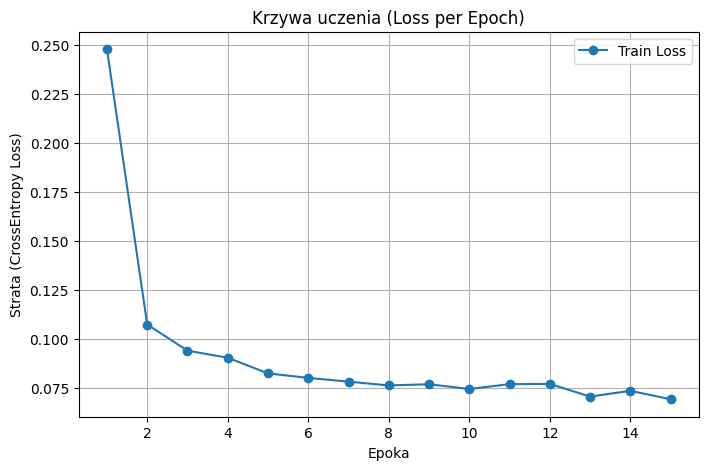


=== WYNIKI EWALUACJI ===
[Train] Accuracy: 94.03%
[Validation] Accuracy: 99.81%
[Test] Accuracy: 97.45%


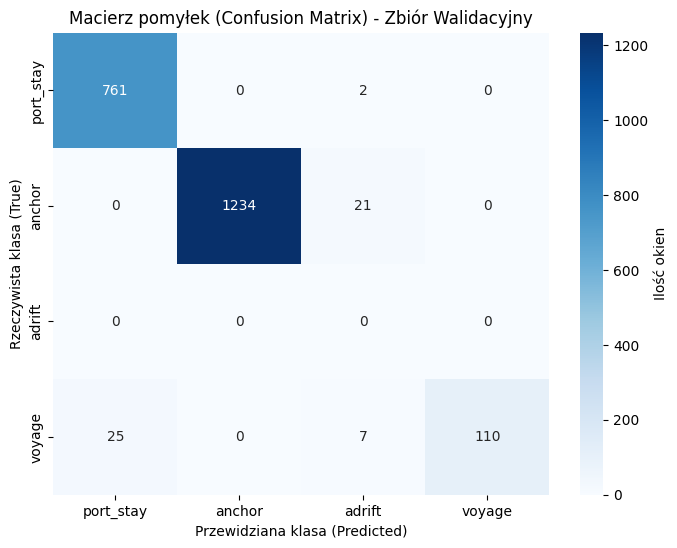

In [ ]:

    # --- PODAJ SWOJE ŚCIEŻKI TUTAJ ---
TRAIN_CSV = r"C:\Users\TMMsi\Desktop\marine_recognition\data\raw\classified\Ship_Operation_example_dataset_classified.csv"
PORTS_CSV = r"C:\Users\TMMsi\Desktop\marine_recognition\data\ports\EU_Port_Codes.csv"

    
# 1. Wczytanie i globalny preprocesing
print("Wczytywanie i preprocesing danych...")
df_all = load_data(TRAIN_CSV)

df_all = detect_and_handle_outliers(df_all)


preprocessor = DataPreprocessor()
df_all_proc = preprocessor.process(df_all)


    # 2. Podział na zbiory (Train: 70%, Val: 15%, Test: 15%)
n = len(df_all_proc)
train_idx = int(n * 0.70)
val_idx = int(n * 0.85)

df_train = df_all_proc.iloc[:train_idx].copy()
df_val = df_all_proc.iloc[train_idx:val_idx].copy()
df_test = df_all_proc.iloc[val_idx:].copy()
print(f"Rozmiary zbiorów (wiersze) - Train: {len(df_train)}, Val: {len(df_val)}, Test: {len(df_test)}\n")


    # 3. Trenowanie modelu
models = train_hierarchical_model(df_train, epochs=15, window_size=10)

    # 4. Rysowanie krzywej uczenia z loss-em
models["sea_model"].plot_learning_curve()

    # 5. metryki Accuracy
print("\n=== WYNIKI EWALUACJI ==
_ = evaluate_pipeline(models, df_train, PORTS_CSV, dataset_name="Train")
_, preds_val_df, y_true_val, y_pred_val = evaluate_pipeline(models, df_val, PORTS_CSV, dataset_name="Validation")
_, preds_test_df, y_true_test, y_pred_test = evaluate_pipeline(models, df_test, PORTS_CSV, dataset_name="Test")
    # 6. Rysowanie Confusion Matrix na zbiorze Treningowym
labels = ["port_stay", "anchor", "adrift", "voyage"]
cm = confusion_matrix(y_true_test, y_pred_test, labels=labels)

    
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, cbar_kws={'label': 'Ilość okien'})
plt.title('Macierz pomyłek (Confusion Matrix) - Zbiór Walidacyjny')
plt.ylabel('Rzeczywista klasa (True)')
plt.xlabel('Przewidziana klasa (Predicted)')
plt.show()

---
## Model rule-based do analizy ruchu statku

### Architektura (`RuleClassifier`)

Model jest systemem opartym na regułach if/else, przystosowanym do klasyfikacji operacji jednostki na podstawie progowych wartości parametrów fizycznych statku,
takich jak prędkość czy przyspieszenie.

#### Struktura:
- **Wejście,** parametry fizyczne statku: 
  - rolling_sog_kn (średni SOG w oknie)
  - rolling_spread_m (środek ciężkości okna)
  - rolling_net_displacement_m (odległość między początkiem, a końcem okna)
- **Rules,** Reguły wczytane z configu `rule_based.yaml`:
  - `At Sea Voyage`, jeżeli $rolling_sog_kn > 3.0$,
  - `At Sea Anchor`, gdy:
    - $rollings_sog_kn$ \ge 0.5$
    - $rollings_spread_m < 200.0$
  - `At Drift`, gdy: 
    - $rolling\_sog\_kn \in [0.3, 3.0]$
    - $rolling\_spread\_m > 200.0$
    - $rolling\_net\_displacement\_m \ge 0.3 \cdot rolling\_spread\_m$,
  - `At Drift` - wartość domyślna, żadna z powyższych reguł nie jest spełniona
- **Agregacja:**
  - Parametr `min_episode_minutes` (domyślnie 50)
- **Wyjście:**
  - 3 klasy - `At Sea Voyage`, `At Sea Anchor`, `At Drift`

---

### Jak działa klasyfikacja:

1. Algorytm dla każdego punktu danych sprawdza listę reguł  
2. Przypisuje rekordowi klasę, dla której wszystkie warunki są spełnione
3. Przypisane klasy są analizowane pod kątem czasu trwania. Jeżeli epizod trwa krócej niż `min_episode_minutes`
i nie jest przerwany luką w sygnale GPS `is_gap`, jego klasa jest nadpisywana przez klasę z poprzedniego epizodu.

---
### Funkcje:

- **Classify**
  - Zwraca bazę danych z przewidywaną klasą oraz poziomem pewności zdefiniowanym w configu przy regule. Wygładza dane.

- **Save**
  - Zapisuje strukturę reguł wraz z parametrem `min_episode_minutes`

- **Load**
  - Umożliwia odtworzenie logiki zapisanego modelu rule-based
---

## Podsumowanie

Model klasyfikuje zdarzenia za pomocą zdefiniowanych reguł, które można zapisać, by odtworzyć logikę.

In [ ]:

ALL_STATES = ["port_stay", "voyage", "anchor", "adrift"]

OPERATION_ID_TO_STATE = {1: "port_stay", 2: "anchor", 3: "adrift", 4: "voyage"}

DEFAULT_RULES = [
    {
        "state": "voyage",
        "confidence": 85,
        "conditions": {"rolling_sog_kn": {"min": 3.0}},
    },
    {
        "state": "adrift",
        "confidence": 70,
        "conditions": {
            "rolling_sog_kn": {"min": 0.3, "max": 3.0},
            "rolling_spread_m": {"min": 200.0},
            "rolling_net_displacement_m": {"min_ratio": {"of": "rolling_spread_m", "value": 0.3}},
        },
    },
    {
        "state": "anchor",
        "confidence": 70,
        "conditions": {
            "rolling_sog_kn": {"max": 0.5},
            "rolling_spread_m": {"max": 200.0},
        },
    },
    {
        "state": "anchor",
        "confidence": 40,
        "conditions": {"rolling_spread_m": {"max": 200.0}},
    },
    {
        "state": "adrift",
        "confidence": 35,
        "conditions": {},
    },
]


class RuleClassifier:
    def __init__(self, rules: list[dict] | None = None, min_episode_minutes: int = 50) -> None:
        self.rules = rules or DEFAULT_RULES
        self.min_episode_minutes = min_episode_minutes

    def classify(self, df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()
        states, confidences = self._apply_rules(df)
        df["predicted_state"] = states
        df["confidence"] = confidences

        gap_boundaries = df.index[df["is_gap"] == 1].tolist() if "is_gap" in df.columns else [0]
        df["predicted_state"] = self._smooth_episodes(
            df["predicted_state"].values, gap_boundaries
        )
        return df

    def _apply_rules(self, df: pd.DataFrame) -> tuple[np.ndarray, np.ndarray]:
        n = len(df)
        states = np.full(n, "adrift", dtype=object)
        confidences = np.full(n, 35.0)

        feature_cache = {}
        for col in df.columns:
            if df[col].dtype in (np.float64, np.int64, float, int):
                feature_cache[col] = df[col].fillna(0).values

        for i in range(n):
            for rule in self.rules:
                if self._check_conditions(rule.get("conditions", {}), feature_cache, i):
                    states[i] = rule["state"]
                    confidences[i] = float(rule.get("confidence", 50))
                    break

        return states, confidences

    def _check_conditions(
        self, conditions: dict, features: dict[str, np.ndarray], idx: int
    ) -> bool:
        if not conditions:
            return True

        for col, constraint in conditions.items():
            if col not in features:
                return False

            val = features[col][idx]

            if isinstance(constraint, dict):
                if "min" in constraint and val < constraint["min"]:
                    return False
                if "max" in constraint and val > constraint["max"]:
                    return False
                if "min_ratio" in constraint:
                    ratio_cfg = constraint["min_ratio"]
                    ref_col = ratio_cfg["of"]
                    ratio_val = ratio_cfg["value"]
                    if ref_col not in features:
                        return False
                    ref_val = features[ref_col][idx]
                    if val < ref_val * ratio_val:
                        return False
            else:
                if val != constraint:
                    return False

        return True

    def _smooth_episodes(
        self, states: np.ndarray, gap_boundaries: list[int]
    ) -> np.ndarray:
        result = states.copy()
        min_len = self.min_episode_minutes
        gap_set = set(gap_boundaries)

        i = 0
        while i < len(result):
            if i in gap_set and i > 0:
                i += 1
                continue
            j = i
            while j < len(result) and result[j] == result[i] and j not in gap_set:
                j += 1
            if j < len(result) and j in gap_set and result[j] == result[i]:
                while j < len(result) and result[j] == result[i]:
                    j += 1

            episode_len = j - i
            if episode_len < min_len and i > 0 and j < len(result):
                result[i:j] = result[i - 1]

            i = j

        return result

    def save(self, path: Path) -> None:
        path.mkdir(parents=True, exist_ok=True)
        data = {
            "rules": self.rules,
            "min_episode_minutes": self.min_episode_minutes,
        }
        with open(path / "rule_params.json", "w") as f:
            json.dump(data, f, indent=2)

    @classmethod
    def load(cls, path: Path) -> RuleClassifier:
        with open(path / "rule_params.json") as f:
            data = json.load(f)
        if "rules" in data:
            return cls(rules=data["rules"], min_episode_minutes=data.get("min_episode_minutes", 50))
        return cls(min_episode_minutes=data.get("min_episode_minutes", 50))

## Przygotowanie danych (Preprocessing)

Surowe dane wejściowe poddawane są sekwencyjnej obróbce w następujących krokach:

1. **Formatowanie czasu:** Konwersja kolumny `signaldate` na typ `datetime` oraz sortowanie danych rosnąco na jej podstawie.
2. **Kinematyka i filtrowanie:** Wyliczenie parametrów ruchu statku (`SOG`, `COG`, `acceleration`, `ROT`) na podstawie ostatniego, poprawnego punktu oraz jednoczesne oznaczenie outlier'ów (zgodnie z [warunkami wykrywania outlierów](#warunki-outlier)).
3. **Detekcja przerw:** Oznaczanie luk w transmisji sygnału, jeśli czas między kolejnymi rekordami przekracza 5 minut. Na tej podstawie, dane są dzielone na segmenty, na których prowadzone są późniejsze obliczenia.
4. **Agregacja w oknie:** Wyliczenie wygładzonych i uśrednionych parametrów ruchu w oknie, które nie przekracza przerw w danych (gaps).

In [ ]:

HIGHEST_POSSIBLE_SOG = 30.0
HIGHEST_POSSIBLE_ACCELERATION = 0.03
HIGHEST_POSSIBLE_TURN = 0.8

EARTH_RADIUS_M = 6_371_000
GAP_THRESHOLD_S = 300


def calculate_bearing(lat1: float, lon1: float, lat2: float, lon2: float) -> float:
    try:
        p_lat, p_lon, c_lat, c_lon = np.radians(
            [float(lat1), float(lon1), float(lat2), float(lon2)]
        )
        d_lon = c_lon - p_lon
        y = np.sin(d_lon) * np.cos(c_lat)
        x = np.cos(p_lat) * np.sin(c_lat) - np.sin(p_lat) * np.cos(c_lat) * np.cos(
            d_lon
        )
        return (np.degrees(np.arctan2(y, x)) + 360) % 360
    except Exception:
        return np.nan


def haversine(
    lat1: np.ndarray, lon1: np.ndarray, lat2: np.ndarray, lon2: np.ndarray
) -> np.ndarray:
    lat1, lat2 = np.radians(lat1), np.radians(lat2)
    lon1, lon2 = np.radians(lon1), np.radians(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * EARTH_RADIUS_M * np.arcsin(np.sqrt(a))


def preprocess(df: pd.DataFrame, rolling_window: int = 45) -> pd.DataFrame:
    """Full preprocessing: kinematics, outlier detection, gap marking, rolling features."""
    df = df.copy()
    df["LAT"] = pd.to_numeric(df["LAT"], errors="coerce")
    df["LON"] = pd.to_numeric(df["LON"], errors="coerce")
    df["signaldate"] = pd.to_datetime(df["signaldate"])
    df = df.sort_values(by="signaldate").reset_index(drop=True)

    df = _compute_kinematics_and_outliers(df)
    df = _mark_gaps(df)
    df = _compute_rolling_features(df, rolling_window=rolling_window)

    return df


def _compute_kinematics_and_outliers(df: pd.DataFrame) -> pd.DataFrame:
    """Compute SOG, COG, acceleration, ROT and flag outliers.

    Each point is compared against the last VALID point, so outliers
    don't corrupt subsequent calculations.
    """
    out_sog, out_cog, out_accel, out_rot, is_outlier = [], [], [], [], []

    last_valid_row = None
    last_valid_sog = 0.0
    last_valid_cog = np.nan

    for index, row in df.iterrows():
        if pd.isna(row["LAT"]) or pd.isna(row["LON"]):
            out_sog.append(np.nan)
            out_cog.append(np.nan)
            out_accel.append(np.nan)
            out_rot.append(np.nan)
            is_outlier.append(1)
            continue

        if last_valid_row is None:
            out_sog.append(0.0)
            out_cog.append(np.nan)
            out_accel.append(0.0)
            out_rot.append(0.0)
            is_outlier.append(0)
            last_valid_row = row
            last_valid_sog = 0.0
            continue

        time_diff = (row["signaldate"] - last_valid_row["signaldate"]).total_seconds()

        if time_diff <= 0:
            out_sog.append(last_valid_sog)
            out_cog.append(last_valid_cog)
            out_accel.append(0.0)
            out_rot.append(0.0)
            is_outlier.append(1)
            continue

        try:
            prev_pos = (float(last_valid_row["LAT"]), float(last_valid_row["LON"]))
            curr_pos = (float(row["LAT"]), float(row["LON"]))
            dist_meters = geodesic(prev_pos, curr_pos).meters
        except Exception:
            dist_meters = 0.0

        current_sog = (dist_meters / time_diff) * 1.94384
        current_cog = calculate_bearing(
            prev_pos[0], prev_pos[1], curr_pos[0], curr_pos[1]
        )

        curr_sog_ms = current_sog * 0.51444
        prev_sog_ms = last_valid_sog * 0.51444
        current_accel = (curr_sog_ms - prev_sog_ms) / time_diff

        p_cog = last_valid_cog if not pd.isna(last_valid_cog) else current_cog
        delta_cog = (current_cog - p_cog + 180) % 360 - 180
        current_rot = (delta_cog / time_diff) * 60

        outlier_flag = 0
        if current_sog > HIGHEST_POSSIBLE_SOG:
            outlier_flag = 1
        elif abs(current_accel) > HIGHEST_POSSIBLE_ACCELERATION:
            outlier_flag = 1
        elif current_sog > 1.0 and (
            current_sog * abs(current_rot) / 1100
        ) > HIGHEST_POSSIBLE_TURN:
            outlier_flag = 1

        out_sog.append(current_sog)
        out_cog.append(current_cog)
        out_accel.append(current_accel)
        out_rot.append(current_rot)
        is_outlier.append(outlier_flag)

        if outlier_flag == 0:
            last_valid_row = row
            last_valid_sog = current_sog
            last_valid_cog = current_cog

    df["sog_knots"] = out_sog
    df["cog"] = out_cog
    df["acceleration"] = out_accel
    df["rot"] = out_rot
    df["outlier_gps"] = is_outlier

    return df


def _mark_gaps(df: pd.DataFrame) -> pd.DataFrame:
    time = pd.to_datetime(df["signaldate"])
    dt = time.diff().dt.total_seconds().values
    is_gap = np.zeros(len(df), dtype=int)
    is_gap[0] = 1
    is_gap[1:] = (np.nan_to_num(dt[1:], nan=9999) > GAP_THRESHOLD_S).astype(int)
    df["is_gap"] = is_gap
    return df


def _compute_rolling_features(
    df: pd.DataFrame, rolling_window: int = 45
) -> pd.DataFrame:
    """Compute rolling features over a centered window.

    Spatial features (haversine per-point):
    - rolling_spread_m: maks. odleglosc punktu od srodka ciezkosci okna.
      port_stay < 13m, anchor < 200m, adrift/voyage > 200m.
    - rolling_net_displacement_m: odleglosc pierwszy-ostatni punkt w oknie.
      Duza przy duzym spread = dryf, mala = kotwica.

    Aggregated features (rolling mean/std of per-point kinematics):
    - rolling_sog_kn: srednia SOG w oknie
    - rolling_sog_std: odchylenie std SOG — stabilnosc predkosci
    - rolling_accel_abs: sredni |acceleration| — aktywnosc manewrowa
    - rolling_rot_abs: sredni |ROT| — intensywnosc skretow
    - rolling_cog_std: circular std kursu — stabilnosc kierunku
    """
    w = rolling_window
    gap_boundaries = df.index[df["is_gap"] == 1].tolist()
    segments = _split_by_gaps(len(df), gap_boundaries)

    sog = df["sog_knots"].fillna(0)
    accel = df["acceleration"].fillna(0).abs()
    rot = df["rot"].fillna(0).abs()

    rolling_sog = pd.Series(np.nan, index=df.index)
    rolling_sog_std = pd.Series(0.0, index=df.index)
    rolling_accel = pd.Series(0.0, index=df.index)
    rolling_rot = pd.Series(0.0, index=df.index)
    rolling_cog_std = pd.Series(0.0, index=df.index)

    for start, end in segments:
        seg_sog = sog.iloc[start:end]
        rolling_sog.iloc[start:end] = seg_sog.rolling(w, center=True, min_periods=1).mean()
        rolling_sog_std.iloc[start:end] = seg_sog.rolling(w, center=True, min_periods=1).std().fillna(0)

        seg_accel = accel.iloc[start:end]
        rolling_accel.iloc[start:end] = seg_accel.rolling(w, center=True, min_periods=1).mean()

        seg_rot = rot.iloc[start:end]
        rolling_rot.iloc[start:end] = seg_rot.rolling(w, center=True, min_periods=1).mean()

        seg_cog = df["cog"].iloc[start:end].ffill().fillna(0)
        rolling_cog_std.iloc[start:end] = _circular_rolling_std(seg_cog.values, w)

    df["rolling_sog_kn"] = rolling_sog
    df["rolling_sog_std"] = rolling_sog_std
    df["rolling_accel_abs"] = rolling_accel
    df["rolling_rot_abs"] = rolling_rot
    df["rolling_cog_std"] = rolling_cog_std

    lat = df["LAT"].values
    lon = df["LON"].values
    n = len(df)
    spread = np.zeros(n)
    net_disp = np.zeros(n)
    half = w // 2

    for start, end in segments:
        for i in range(start, end):
            lo = max(start, i - half)
            hi = min(end, i + half + 1)
            if hi - lo < 2:
                continue

            wlat = lat[lo:hi]
            wlon = lon[lo:hi]
            clat, clon = wlat.mean(), wlon.mean()
            dists = haversine(
                wlat, wlon, np.full(hi - lo, clat), np.full(hi - lo, clon)
            )
            spread[i] = dists.max()
            net_disp[i] = haversine(
                np.array([lat[lo]]),
                np.array([lon[lo]]),
                np.array([lat[hi - 1]]),
                np.array([lon[hi - 1]]),
            )[0]

    df["rolling_spread_m"] = spread
    df["rolling_net_displacement_m"] = net_disp

    return df


def _circular_rolling_std(angles_deg: np.ndarray, window: int) -> np.ndarray:
    rad = np.radians(angles_deg)
    sin_vals = np.sin(rad)
    cos_vals = np.cos(rad)
    n = len(angles_deg)
    result = np.zeros(n)
    half = window // 2

    for i in range(n):
        lo = max(0, i - half)
        hi = min(n, i + half + 1)
        s_mean = sin_vals[lo:hi].mean()
        c_mean = cos_vals[lo:hi].mean()
        r = np.sqrt(s_mean**2 + c_mean**2)
        result[i] = np.degrees(np.sqrt(-2 * np.log(max(r, 1e-10))))

    return result


def _split_by_gaps(n: int, gap_boundaries: list[int]) -> list[tuple[int, int]]:
    boundaries = sorted(set(gap_boundaries) | {0})
    segments = []
    for idx, start in enumerate(boundaries):
        end = boundaries[idx + 1] if idx + 1 < len(boundaries) else n
        if end > start:
            segments.append((start, end))
    return segments


## Pipeline ##

Poniższy kod wykonuje pipeline modelu rule-based: wyszukanie outlier'ów, preprocessing, klasyfikację, walidację oraz wizualizację wyników.
---

### Importy ###

In [9]:
%load_ext autoreload
%autoreload 2

import sys
import os

if os.path.basename(os.getcwd()) == "notebook":
    os.chdir("..") 

sys.path.append(os.path.abspath('.'))

from pathlib import Path
import pandas as pd
from geopy.distance import geodesic
from src.config import Config
from src.data.oversampling import oversample_minority
from src.data.ports import load_port_matcher
from src.data.splitter import split_by_episodes
from src.evaluation.metrics import compute_all_metrics, print_metrics, save_metrics
from src.evaluation.plots import plot_all_splits
from src.models.rule_based import OPERATION_ID_TO_STATE, RuleClassifier
from src.models.decision_tree import TreeClassifier
from src.data.preprocessing import preprocess

Loading data\raw\Ship_Operation_example_dataset_classified.csv...
Loading data\raw\Ship_Operation_example_dataset_classified_2.csv...
Total rows: 30242
Preprocessing (kinematics + outliers + rolling features)...
Outliers detected: 23 / 30242 (0.08%)
Matching ports from data/ports (radius=3000.0m)...
  Loaded 7184 ports from EU_Port_Codes.csv
  Loaded 333 ports from ports-converted.csv
  Total unique ports: 7461
Points in port: 809 / 30242 (2.7%)
Saved to data\preprocessed\preprocessed.csv (30242 rows)
Matching ports...
  Loaded 7184 ports from EU_Port_Codes.csv
  Loaded 333 ports from ports-converted.csv
  Total unique ports: 7461
  In port: 809 / 30242
Splitting data...
  Split train: 12513 rows, states=[np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
  Split val: 1036 rows, states=[np.int64(1), np.int64(2), np.int64(4)]
  Split test: 16693 rows, states=[np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
  Oversampled adrift: 260 -> 3x (1 episodes)
Training model: rule_based
[tra

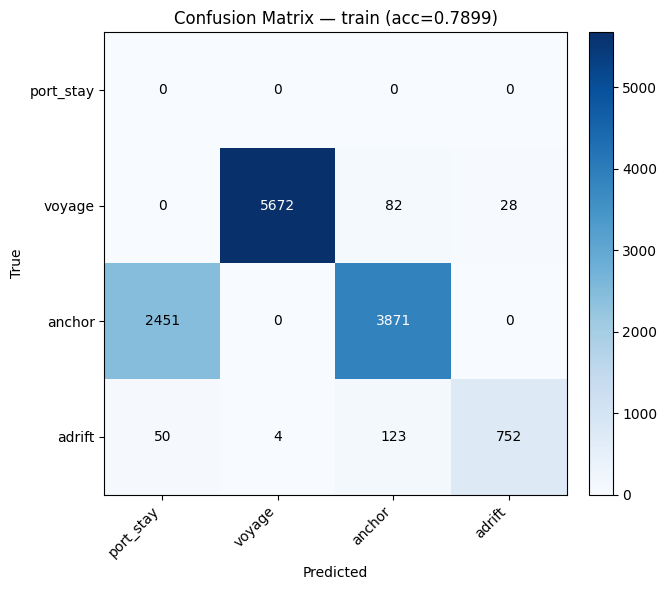

  Plot saved: reports\rule_v1\confusion_matrix_train.png


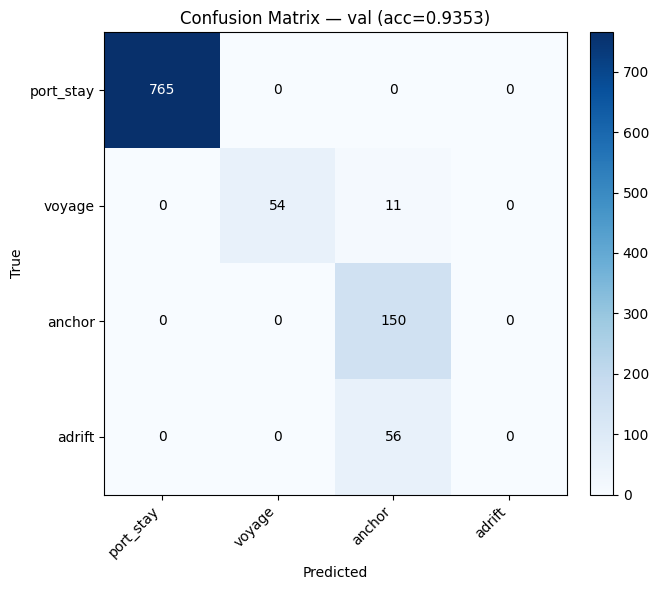

  Plot saved: reports\rule_v1\confusion_matrix_val.png


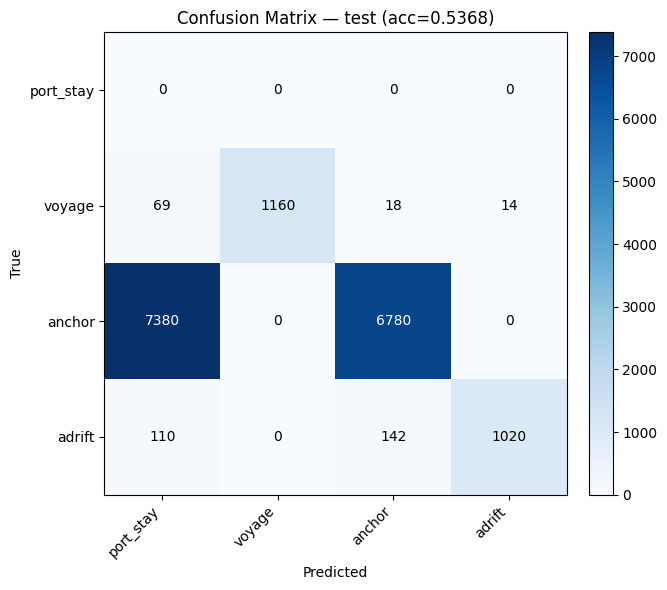

  Plot saved: reports\rule_v1\confusion_matrix_test.png

Model saved to models\rule_v1
Metrics saved to reports\rule_v1\metrics.json


In [14]:
# 1. Wczytanie configu i preprocessing
CONFIG_PATH = './configs/rule_based.yaml'
cfg = Config.from_yaml(CONFIG_PATH)

raw_dir = Path(cfg.paths.raw_dir)
input_files = [str(raw_dir / f) for f in cfg.data.input_files]

frames = []
for f in input_files:
    print(f"Loading {f}...")
    frames.append(pd.read_csv(f))
df = pd.concat(frames, ignore_index=True)
print(f"Total rows: {len(df)}")

print("Preprocessing (kinematics + outliers + rolling features)...")
rolling_window = cfg.preprocessing.get("rolling_window", 45)
df = preprocess(df, rolling_window=rolling_window)
outlier_count = int(df["outlier_gps"].sum())
print(f"Outliers detected: {outlier_count} / {len(df)} ({100*outlier_count/len(df):.2f}%)")

ports_dir = cfg.paths.ports_dir
port_radius = cfg.port.get("radius_meters", 5000.0)
if Path(ports_dir).exists():
    print(f"Matching ports from {ports_dir} (radius={port_radius}m)...")
    matcher = load_port_matcher(ports_dir, port_radius)
    port_info = matcher.match(df["LAT"].values, df["LON"].values)
    df = df.join(port_info)
    in_port_count = int(df["in_port"].sum())
    print(f"Points in port: {in_port_count} / {len(df)} ({100*in_port_count/len(df):.1f}%)")
else:
    print(f"Port directory not found at {ports_dir}, skipping port matching")

output = Path(str(Path(cfg.paths.preprocessed_dir) / "preprocessed.csv"))
output.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(output, index=False)
print(f"Saved to {output} ({len(df)} rows)")

df["signaldate"] = pd.to_datetime(df["signaldate"])
df["state"] = df["operation_id"].map(OPERATION_ID_TO_STATE)

# 2. Detekcja portów
ports_dir = Path(cfg.paths.ports_dir)
port_radius = cfg.port.get("radius_meters", 3000.0)
if ports_dir.exists():
    print("Matching ports...")
    matcher = load_port_matcher(str(ports_dir), port_radius)
    port_cols = ["in_port", "nearest_locode", "port_distance_m"]
    df = df.drop(columns=[c for c in port_cols if c in df.columns])
    port_info = matcher.match(df["LAT"].values, df["LON"].values)
    df = df.join(port_info)
    in_port_count = int(df["in_port"].sum())
    print(f"  In port: {in_port_count} / {len(df)}")

# 3. Podział danych na zbiory (Val: 20%, Test: 15%)
seed = cfg.get("random_seed", 42)
test_size = cfg.training.get("test_size", 0.2)
val_size = cfg.training.get("validation_size", 0.15)

print("Splitting data...")
splits = split_by_episodes(df, seed=seed, test_size=test_size, val_size=val_size)

max_ratio = cfg.training.get("oversampling_max_ratio", 3)
splits["train"] = oversample_minority(splits["train"], max_ratio=max_ratio)

model_name = cfg.model.get("name", "rule_based")
print(f"Training model: {model_name}")

# 4. Budowa klasyfikatora
model_name = cfg.model.get("name", "rule_based")
rules = cfg.model.get("rules", None)
if isinstance(rules, Config):
    rules = None
min_ep = cfg.model.get("min_episode_minutes", 50)
classifier = RuleClassifier(rules=rules, min_episode_minutes=min_ep)

if isinstance(classifier, TreeClassifier):
    classifier.fit(splits["train"])

# 5. Klasyfikacja operacji
results = {}
for split_name, split_df in splits.items():
    predicted = classifier.classify(split_df)
    if "in_port" in predicted.columns:
        port_mask = (predicted["in_port"].values == 1) & (predicted["predicted_state"].isin(["anchor", "adrift"]))
        predicted.loc[port_mask, "predicted_state"] = "port_stay"
        predicted.loc[port_mask, "confidence"] = 100.0
    metrics = compute_all_metrics(
        predicted["state"].values, predicted["predicted_state"].values
    )
    results[split_name] = metrics
    print_metrics(metrics, split_name)

# 6. Zapisanie parametrów modelu
model_dir = Path(cfg.paths.models_dir) / cfg.experiment_name
classifier.save(model_dir)

reports_dir = Path(cfg.paths.reports_dir) / cfg.experiment_name
save_metrics(results, reports_dir / "metrics.json")

# 7. Wizualizacja wyników
print("\nGenerating confusion matrix plots...")
plot_all_splits(results, reports_dir)

test_predicted = classifier.classify(splits["test"])
if "in_port" in test_predicted.columns:
    port_mask = test_predicted["in_port"].values == 1
    test_predicted.loc[port_mask, "predicted_state"] = "port_stay"
    test_predicted.loc[port_mask, "confidence"] = 100.0
test_predicted.to_csv(reports_dir / "test_predictions.csv", index=False)

print(f"\nModel saved to {model_dir}")
print(f"Metrics saved to {reports_dir / 'metrics.json'}")